# Task 3.2 - SMS Spam Classifier (TensorFlow/Keras)

## Problem statement
Classify an SMS message as **spam** or **ham** (legitimate) from its text alone.
A prediction is useful if it catches most spam (high recall on spam) without
wrongly blocking real messages (high precision on spam). Because spam is the
minority class, accuracy alone will not be a reliable measure.

## Dataset
SMS Spam Collection, UCI Machine Learning Repository (5,574 English messages, each
labeled ham or spam). The raw file is kept unchanged in `data/raw/`.

## Plan
1. Inspect the data (class counts, duplicates, message length)
2. Split into train/test before any text processing
3. Build a simple baseline
4. Train a Keras text model
5. Evaluate with precision, recall, F1 and a confusion matrix
6. Inspect misclassified messages
7. Save the model and build an inference function

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "../data/raw/SMSSpamCollection"

df = pd.read_csv(
    DATA_PATH, sep="\t", header=None, names=["label", "text"], quoting=3
)

print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nClass counts:\n", df["label"].value_counts())
print("\nClass percentages:\n", (df["label"].value_counts(normalize=True) * 100).round(2))
print("\nExact duplicate rows:", df.duplicated().sum())
df.head()

Shape: (5574, 2)

Missing values:
 label    0
text     0
dtype: int64

Class counts:
 label
ham     4827
spam     747
Name: count, dtype: int64

Class percentages:
 label
ham     86.6
spam    13.4
Name: proportion, dtype: float64

Exact duplicate rows: 403


,label,text
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply ...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives around here though"


## Exploratory analysis
Questions: (1) Which messages are duplicated, and do any texts carry conflicting labels?
(2) How does message length differ between spam and ham? (3) What do real spam and ham
messages look like?

In [ ]:
pd.set_option("display.max_colwidth", 90)

extra_copies = df[df.duplicated()]
print("Extra copies (rows duplicated() counted):", len(extra_copies))
print("Labels of those extra copies:\n", extra_copies["label"].value_counts())

label_counts_per_text = df.groupby("text")["label"].nunique()
print("\nTexts that appear with BOTH labels:", (label_counts_per_text > 1).sum())

print("\nMost repeated messages:")
print(df["text"].value_counts().head(8))

      length             word_count            
        mean median  max       mean median  max
label                                          
ham     71.5   52.0  910       14.3   11.0  171
spam   138.7  149.0  223       23.9   25.0   35


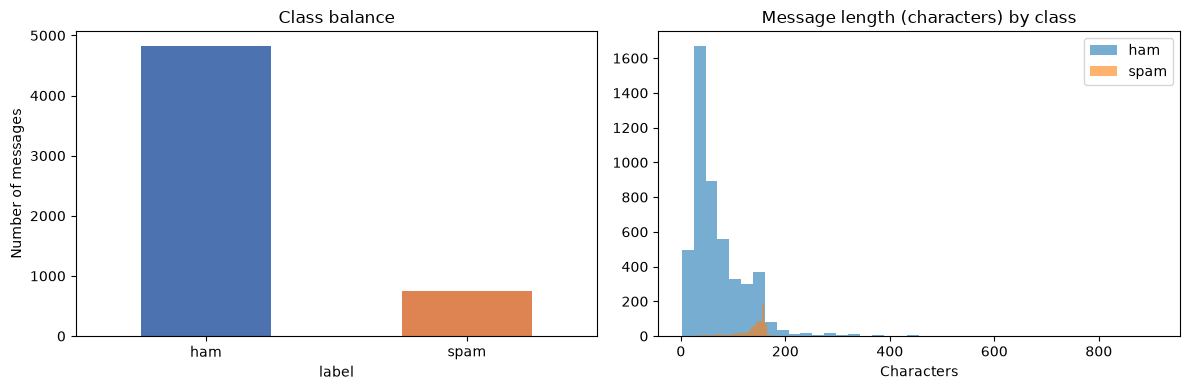

In [24]:
df["length"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()

print(df.groupby("label")[["length", "word_count"]].agg(["mean", "median", "max"]).round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["label"].value_counts().plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_title("Class balance")
axes[0].set_ylabel("Number of messages")
axes[0].tick_params(axis="x", rotation=0)

for lab in ["ham", "spam"]:
    axes[1].hist(df[df["label"] == lab]["length"], bins=40, alpha=0.6, label=lab)
axes[1].set_title("Message length (characters) by class")
axes[1].set_xlabel("Characters")
axes[1].legend()

plt.tight_layout()
plt.savefig("../results/eda_class_balance_and_length.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
print("=== 5 random SPAM ===")
for t in df[df["label"] == "spam"]["text"].sample(5, random_state=42):
    print("-", t, "\n")

print("=== 5 random HAM ===")
for t in df[df["label"] == "ham"]["text"].sample(5, random_state=42):
    print("-", t, "\n")

## Preprocessing decisions
- Exact duplicate messages are removed before splitting (no text carries conflicting labels).
- Labels: spam = 1, ham = 0.
- 80/20 stratified split with random_state=42, done before any text processing.

In [26]:
from sklearn.model_selection import train_test_split

# 1. Remove exact duplicate messages (the raw file stays untouched)
before = len(df)
df_clean = df.drop_duplicates(subset="text", keep="first").reset_index(drop=True)
print(f"Rows before: {before} | after: {len(df_clean)} | removed: {before - len(df_clean)}")
print(df_clean["label"].value_counts())
print((df_clean["label"].value_counts(normalize=True) * 100).round(2))

# 2. Encode labels
df_clean["y"] = (df_clean["label"] == "spam").astype(int)

# 3. Stratified split BEFORE any text processing
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df_clean["text"], df_clean["y"],
    test_size=0.2, random_state=42, stratify=df_clean["y"],
)

print("\nTrain size:", len(X_train_text), "| spam share:", round(y_train.mean() * 100, 2), "%")
print("Test size: ", len(X_test_text), "| spam share:", round(y_test.mean() * 100, 2), "%")
print("Spam messages in test set:", int(y_test.sum()))

# 4. Leakage check: no identical message should be in both sets
print("Messages in BOTH train and test:", len(set(X_train_text) & set(X_test_text)))

Rows before: 5574 | after: 5171 | removed: 403
label
ham     4518
spam     653
Name: count, dtype: int64
label
ham     87.37
spam    12.63
Name: proportion, dtype: float64

Train size: 4136 | spam share: 12.62 %
Test size:  1035 | spam share: 12.66 %
Spam messages in test set: 131
Messages in BOTH train and test: 0


## Baseline models
Before building a neural network, two baselines set the reference:
(1) always predict ham, and (2) TF-IDF + logistic regression. The TF-IDF vocabulary is
learned from training text only. Spam is the positive class; main metrics are precision,
recall and F1 on spam, plus the confusion matrix.

,model,accuracy,spam_precision,spam_recall,spam_f1,TN,FP,FN,TP
0,Always predict ham,0.8734,0.0000,0.0000,0.0000,904,0,131,0
1,TF-IDF + Logistic Regression,0.9623,0.9894,0.7099,0.8267,903,1,38,93


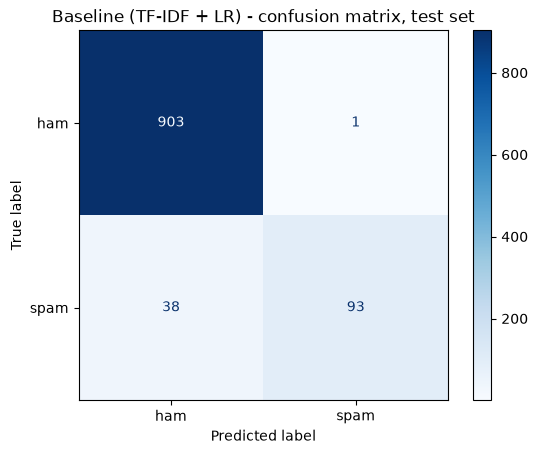

In [27]:
import json
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)

def evaluate(name, y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "model": name,
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "spam_precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "spam_recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "spam_f1": round(f1_score(y_true, y_pred, zero_division=0), 4),
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
    }

# Baseline 1: always predict the majority class (ham)
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(np.zeros((len(X_train_text), 1)), y_train)
dummy_pred = dummy.predict(np.zeros((len(X_test_text), 1)))

# Baseline 2: TF-IDF + logistic regression (vectorizer fit on training text only)
tfidf_lr = Pipeline([
    ("tfidf", TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=2)),
    ("clf", LogisticRegression(max_iter=1000)),
])
tfidf_lr.fit(X_train_text, y_train)
lr_pred = tfidf_lr.predict(X_test_text)

baseline_results = [
    evaluate("Always predict ham", y_test, dummy_pred),
    evaluate("TF-IDF + Logistic Regression", y_test, lr_pred),
]
baseline_df = pd.DataFrame(baseline_results)
display(baseline_df)

with open("../results/baseline_results.json", "w") as f:
    json.dump(baseline_results, f, indent=2)

ConfusionMatrixDisplay.from_predictions(
    y_test, lr_pred, display_labels=["ham", "spam"], cmap="Blues"
)
plt.title("Baseline (TF-IDF + LR) - confusion matrix, test set")
plt.savefig("../results/baseline_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

### Baseline results (test set: 1,035 messages, 131 spam)
| Model | Accuracy | Spam precision | Spam recall | Spam F1 | Missed spam (FN) | False alarms (FP) |
|---|---|---|---|---|---|---|
| Always predict ham | 0.8734 | 0.0000 | 0.0000 | 0.0000 | 131 | 0 |
| TF-IDF + Logistic Regression | 0.9623 | 0.9894 | 0.7099 | 0.8267 | 38 | 1 |

- Always predicting ham scores 87.3% accuracy while catching no spam, so accuracy alone is misleading.
- The logistic regression baseline is very precise (1 false alarm) but misses 38 of 131 spam messages (recall 0.71).
- With only 131 spam messages in the test set, recall has a rough uncertainty of about +/- 8 percentage points, so small differences between models are weak evidence.

## Keras text model
Pipeline: TextVectorization (vocabulary learned from training text only) -> Embedding ->
average pooling -> Dense -> Dropout -> sigmoid output (probability of spam).
A validation set is carved out of the training data to monitor training; the test set
stays untouched until final evaluation.


In [28]:
import tensorflow as tf
from tensorflow import keras

keras.utils.set_random_seed(42)

# 1. Validation split from the TRAINING data only (stratified)
X_tr_text, X_val_text, y_tr, y_val = train_test_split(
    X_train_text, y_train, test_size=0.15, random_state=42, stratify=y_train
)

# Keras wants plain numpy string arrays, shaped (n, 1)
def to_text_array(series):
    return np.array(series.tolist()).reshape(-1, 1)

X_tr_arr = to_text_array(X_tr_text)
X_val_arr = to_text_array(X_val_text)
X_test_arr = to_text_array(X_test_text)

print("Train:", len(X_tr_text), "| spam:", int(y_tr.sum()))
print("Validation:", len(X_val_text), "| spam:", int(y_val.sum()))
print("Test:", len(X_test_text), "| spam:", int(y_test.sum()))

# 2. How long are messages in words? (to choose a sequence length)
words_per_msg = X_tr_text.str.split().str.len()
print("\nShare of training messages longer than 50 words:",
      round((words_per_msg > 50).mean() * 100, 2), "%")

# 3. Text vectorizer - vocabulary learned from training text only
MAX_TOKENS = 5000
SEQ_LEN = 50
vectorizer = keras.layers.TextVectorization(
    max_tokens=MAX_TOKENS, output_mode="int", output_sequence_length=SEQ_LEN
)
vectorizer.adapt(X_tr_arr)
print("Vocabulary size:", vectorizer.vocabulary_size())
print("First 15 vocabulary entries:", vectorizer.get_vocabulary()[:15])

# 4. Model
model = keras.Sequential([
    keras.layers.Input(shape=(1,), dtype="string"),
    vectorizer,
    keras.layers.Embedding(input_dim=MAX_TOKENS, output_dim=16, mask_zero=True),
    keras.layers.GlobalAveragePooling1D(),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[keras.metrics.Precision(name="precision"),
             keras.metrics.Recall(name="recall")],
)
model.summary()

Train: 3515 | spam: 444
Validation: 621 | spam: 78
Test: 1035 | spam: 131

Share of training messages longer than 50 words: 0.97 %
Vocabulary size: 5000
First 15 vocabulary entries: ['', '[UNK]', np.str_('i'), np.str_('you'), np.str_('to'), np.str_('a'), np.str_('the'), np.str_('u'), np.str_('and'), np.str_('in'), np.str_('is'), np.str_('me'), np.str_('my'), np.str_('for'), np.str_('your')]


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_2            │ (None, 50)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 50, 16)         │        80,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 16)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,289 (313.63 KB)

 Trainable params: 80,289 (313.63 KB)

 Non-trainable params: 0 (0.00 B)

## Training and validation
The model is trained with early stopping on validation loss (patience 5, best weights restored).
The test set is not used here. For a fair comparison the TF-IDF baseline is re-fit on the
same 3,515 training messages and scored on the same validation set. Note that the validation
set also picks the stopping epoch, so validation scores are slightly optimistic.

In [29]:
# Convert text to TensorFlow string tensors, shape (n, 1)
X_tr_arr = tf.constant(X_tr_text.tolist(), dtype=tf.string)[:, tf.newaxis]
X_val_arr = tf.constant(X_val_text.tolist(), dtype=tf.string)[:, tf.newaxis]
X_test_arr = tf.constant(X_test_text.tolist(), dtype=tf.string)[:, tf.newaxis]

print(X_tr_arr.shape, X_val_arr.shape, X_test_arr.shape)
print(X_tr_arr.dtype)

(3515, 1) (621, 1) (1035, 1)
<dtype: 'string'>


Epochs run: 17 | best epoch: 12 | training time: 10.5 s


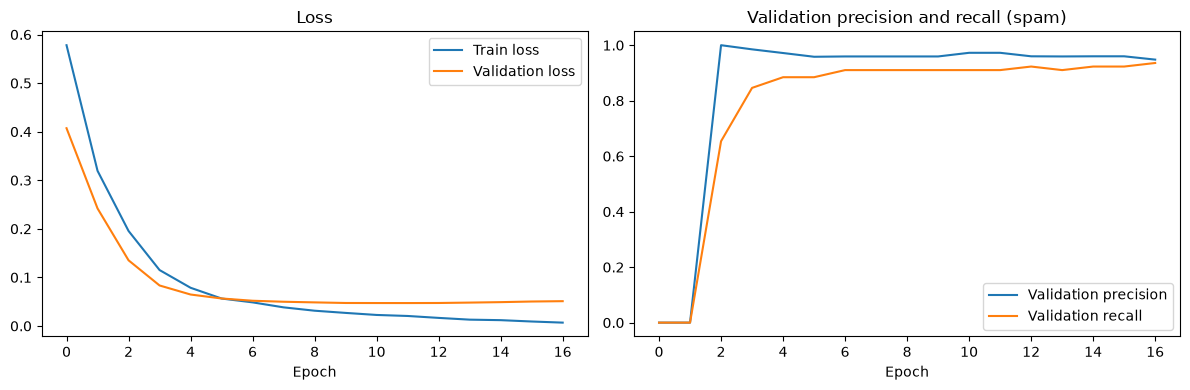

,model,accuracy,spam_precision,spam_recall,spam_f1,TN,FP,FN,TP
0,"TF-IDF + LR (3,515 train)",0.9726,0.9841,0.7949,0.8794,542,1,16,62
1,Keras text model,0.9855,0.9726,0.9103,0.9404,541,2,7,71


In [30]:
import time
from sklearn.base import clone

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

y_tr_arr = y_tr.values.astype("float32")
y_val_arr = y_val.values.astype("float32")

start = time.perf_counter()
history = model.fit(
    X_tr_arr, y_tr_arr,
    validation_data=(X_val_arr, y_val_arr),
    epochs=50, batch_size=32,
    callbacks=[early_stop], verbose=0,
)
train_time = time.perf_counter() - start

epochs_run = len(history.history["loss"])
best_epoch = int(np.argmin(history.history["val_loss"])) + 1
print(f"Epochs run: {epochs_run} | best epoch: {best_epoch} | training time: {train_time:.1f} s")

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"], label="Train loss")
axes[0].plot(history.history["val_loss"], label="Validation loss")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(history.history["val_precision"], label="Validation precision")
axes[1].plot(history.history["val_recall"], label="Validation recall")
axes[1].set_title("Validation precision and recall (spam)")
axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout()
plt.savefig("../results/keras_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# Validation scores at the restored best weights (0.5 cutoff)
val_probs = model.predict(X_val_arr, verbose=0).ravel()
val_pred_keras = (val_probs >= 0.5).astype(int)

# Fair baseline: same pipeline, trained on the same 3,515 messages only
lr_small = clone(tfidf_lr)
lr_small.fit(X_tr_text, y_tr)
val_pred_lr = lr_small.predict(X_val_text)

val_compare = pd.DataFrame([
    evaluate("TF-IDF + LR (3,515 train)", y_val, val_pred_lr),
    evaluate("Keras text model", y_val, val_pred_keras),
])
display(val_compare)

### Validation results (621 messages, 78 spam)
| Model | Accuracy | Spam precision | Spam recall | Spam F1 | Missed spam (FN) | False alarms (FP) |
|---|---|---|---|---|---|---|
| TF-IDF + LR (3,515 train) | 0.9726 | 0.9841 | 0.7949 | 0.8794 | 16 | 1 |
| Keras text model | 0.9855 | 0.9726 | 0.9103 | 0.9404 | 7 | 2 |

- Keras stopped after 17 epochs; best epoch 12 (weights restored); training time 11.0 s.
- Train loss kept falling while validation loss flattened, so extra epochs mostly fit the training set. Early stopping handled this.
- On validation, Keras caught 9 more spam messages (71 vs 62) at the cost of one extra false alarm (2 vs 1).
- Caveats: the validation set also chose the stopping epoch, so these scores are slightly optimistic, and with 78 spam each message is worth about 1.3 percentage points of recall.

In [31]:
val_compare.to_json("../results/validation_results.json", orient="records", indent=2)
with open("../results/keras_training_info.json", "w") as f:
    json.dump({"epochs_run": epochs_run, "best_epoch": best_epoch,
               "training_time_seconds": round(train_time, 1)}, f, indent=2)

### Final evaluation on the test set
The model's weights and vocabulary are saved first (frozen), then the model is scored on the held-out test set (1,035 messages, 131 spam). The cutoff of 0.5 and the epoch-12 weights were fixed before looking at test results. Both TF-IDF baselines are shown: the Step 6 one trained on all 4,136 training messages, and a like-for-like one trained on the same 3,515 as Keras.

In [ ]:
pd.set_option("display.max_colwidth", 140)
errors = pd.DataFrame({
    "text": X_test_text.values,
    "true": np.where(y_test.values == 1, "spam", "ham"),
    "spam_prob": test_probs.round(3),
})
errors = errors[test_pred_keras != y_test.values]

print("Missed spam (false negatives):", int((errors["true"] == "spam").sum()))
display(errors[errors["true"] == "spam"].sort_values("spam_prob"))
print("False alarms (false positives):", int((errors["true"] == "ham").sum()))
display(errors[errors["true"] == "ham"].sort_values("spam_prob", ascending=False))

In [ ]:
import json

model.save_weights("../model/sms_spam_keras.weights.h5")

vocab = vectorizer.get_vocabulary()
with open("../model/vocabulary.json", "w", encoding="utf-8") as f:
    json.dump(vocab, f)   # default settings write plain ASCII escapes

model_config = {"max_tokens": MAX_TOKENS, "seq_len": SEQ_LEN,
                "embedding_dim": 16, "threshold": 0.5}
with open("../model/model_config.json", "w", encoding="utf-8") as f:
    json.dump(model_config, f, indent=2)

print("Saved. Vocabulary entries:", len(vocab))

Saved. Vocabulary entries: 5000


In [36]:
def build_model(vocab_list):
    vec = keras.layers.TextVectorization(
        max_tokens=MAX_TOKENS, output_mode="int", output_sequence_length=SEQ_LEN
    )
    vec.set_vocabulary(vocab_list)
    return keras.Sequential([
        keras.layers.Input(shape=(1,), dtype="string"),
        vec,
        keras.layers.Embedding(input_dim=MAX_TOKENS, output_dim=16, mask_zero=True),
        keras.layers.GlobalAveragePooling1D(),
        keras.layers.Dense(16, activation="relu"),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(1, activation="sigmoid"),
    ])

with open("../model/vocabulary.json", encoding="utf-8") as f:
    vocab_loaded = json.load(f)

rebuilt = build_model(vocab_loaded)
rebuilt.load_weights("../model/sms_spam_keras.weights.h5")

orig_probs = model.predict(X_val_arr, verbose=0).ravel()
new_probs = rebuilt.predict(X_val_arr, verbose=0).ravel()
print("Same vocabulary:", vocab_loaded == vectorizer.get_vocabulary())
print("Max difference in validation probabilities:", float(np.abs(orig_probs - new_probs).max()))

Same vocabulary: True
Max difference in validation probabilities: 0.0


,model,accuracy,spam_precision,spam_recall,spam_f1,TN,FP,FN,TP
0,Always predict ham,0.8734,0.0000,0.0000,0.0000,904,0,131,0
1,"TF-IDF + LR (4,136 train)",0.9623,0.9894,0.7099,0.8267,903,1,38,93
2,"TF-IDF + LR (3,515 train)",0.9614,0.9892,0.7023,0.8214,903,1,39,92
3,"Keras text model (3,515 train)",0.9681,0.8828,0.8626,0.8726,889,15,18,113


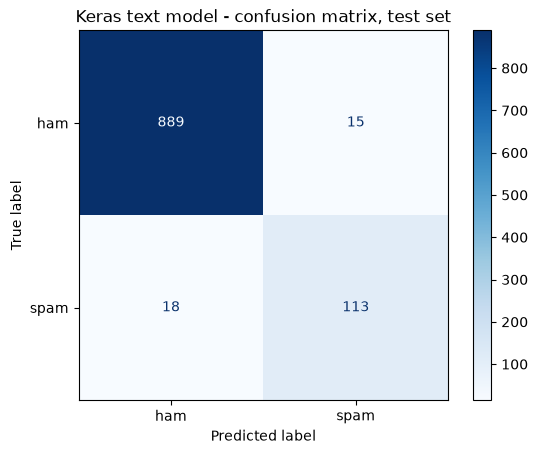

In [ ]:
test_probs = model.predict(X_test_arr, verbose=0).ravel()
test_pred_keras = (test_probs >= 0.5).astype(int)
test_pred_lr_small = lr_small.predict(X_test_text)

test_compare = pd.DataFrame([
    evaluate("Always predict ham", y_test, dummy_pred),
    evaluate("TF-IDF + LR (4,136 train)", y_test, lr_pred),
    evaluate("TF-IDF + LR (3,515 train)", y_test, test_pred_lr_small),
    evaluate("Keras text model (3,515 train)", y_test, test_pred_keras),
])
display(test_compare)
test_compare.to_json("../results/test_results.json", orient="records", indent=2)

ConfusionMatrixDisplay.from_predictions(
    y_test, test_pred_keras, display_labels=["ham", "spam"], cmap="Blues"
)
plt.title("Keras text model - confusion matrix, test set")
plt.savefig("../results/keras_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [33]:
val_probs_now = model.predict(X_val_arr, verbose=0).ravel()
print(evaluate("Keras (in memory now)", y_val, (val_probs_now >= 0.5).astype(int)))
print("Epochs in history:", len(history.history["loss"]),
      "| best epoch:", int(np.argmin(history.history["val_loss"])) + 1)

{'model': 'Keras (in memory now)', 'accuracy': 0.9855, 'spam_precision': 0.9726, 'spam_recall': 0.9103, 'spam_f1': 0.9404, 'TN': 541, 'FP': 2, 'FN': 7, 'TP': 71}
Epochs in history: 17 | best epoch: 12


### Test results (1,035 messages, 131 spam; evaluated after the model and cutoff were frozen)
| Model | Accuracy | Spam precision | Spam recall | Spam F1 | Missed spam (FN) | False alarms (FP) |
|---|---|---|---|---|---|---|
| Always predict ham | 0.8734 | 0.0000 | 0.0000 | 0.0000 | 131 | 0 |
| TF-IDF + LR (4,136 train) | 0.9623 | 0.9894 | 0.7099 | 0.8267 | 38 | 1 |
| TF-IDF + LR (3,515 train) | 0.9614 | 0.9892 | 0.7023 | 0.8214 | 39 | 1 |
| Keras text model (3,515 train) | 0.9681 | 0.8828 | 0.8626 | 0.8726 | 18 | 15 |

- Keras catches more spam (113 vs 92 at the same training size) but raises far more false alarms (15 vs 1): it trades precision for recall.
- Validation looked better than test (2 false alarms among 543 validation ham vs 15 among 904 test ham). The validation set also chose the stopping epoch and is small, so its scores were optimistic.
- 6 of the 15 false alarms had a spam probability above 0.9 (confidently wrong); 7 of the 18 missed spam were below 0.03.
- With 131 spam messages, recall is uncertain by roughly +/- 6 percentage points.
- The test cell was re-run for consistency checks only (inference, no settings changed).

## Observations
**Data.** About 7% of the raw rows (403 of 5,574) were exact duplicates, mostly ham (309 extra ham copies vs 94 extra spam copies). No text appeared with both labels, so I removed the extra copies before splitting. The most repeated messages were short everyday replies, one spam advert and several chain-style messages.

**Length and style.** Spam is longer and more uniform: median 149 characters / 25 words (maximum 223 characters), against 52 characters / 11 words for ham, which also has a very long tail (up to 910 characters). Spam typically mentions prices, short codes, phone numbers, "free" or urgency; ham is informal and uses abbreviations such as "u", "ur" and "pls".

**Errors (test set).** The 15 false alarms were mostly very short, ordinary messages. Several contain words that also appear in spam, such as "your", "message", "text", "account" or "offer", and 6 of them scored above 0.9. One false alarm was a longer message that looks like a promotion for a free-SMS site, so it may be a labeling issue (not verified). Of the 18 missed spam messages, 7 scored below 0.03. Many were adult chat-line adverts and a few were quizzes or competitions. Two missed messages were near-copies of each other, which exact-duplicate removal cannot catch.

**Takeaway.** The TF-IDF model made almost no false alarms but missed about 29% of spam (38 of 131). The neural model caught more spam but flagged 15 real messages. Which is better depends on whether blocking a real message or letting spam through is the costlier mistake.

These are my readings of the error tables, not tested explanations. Checking them would need a per-word analysis.

In [ ]:
test_probs_rebuilt = rebuilt.predict(X_test_arr, verbose=0).ravel()
print(evaluate("Keras rebuilt from saved files", y_test, (test_probs_rebuilt >= 0.5).astype(int)))

In [ ]:
import sys
sys.path.insert(0, "..")
from predict_sms import predict_sms

for t, p in zip(X_val_text.iloc[:5].tolist(), orig_probs[:5]):
    print(round(float(p), 4), predict_sms(t)["spam_probability"])

0.0011 0.0011
0.0015 0.0015
0.1004 0.1004
0.0003 0.0003
0.0001 0.0001
